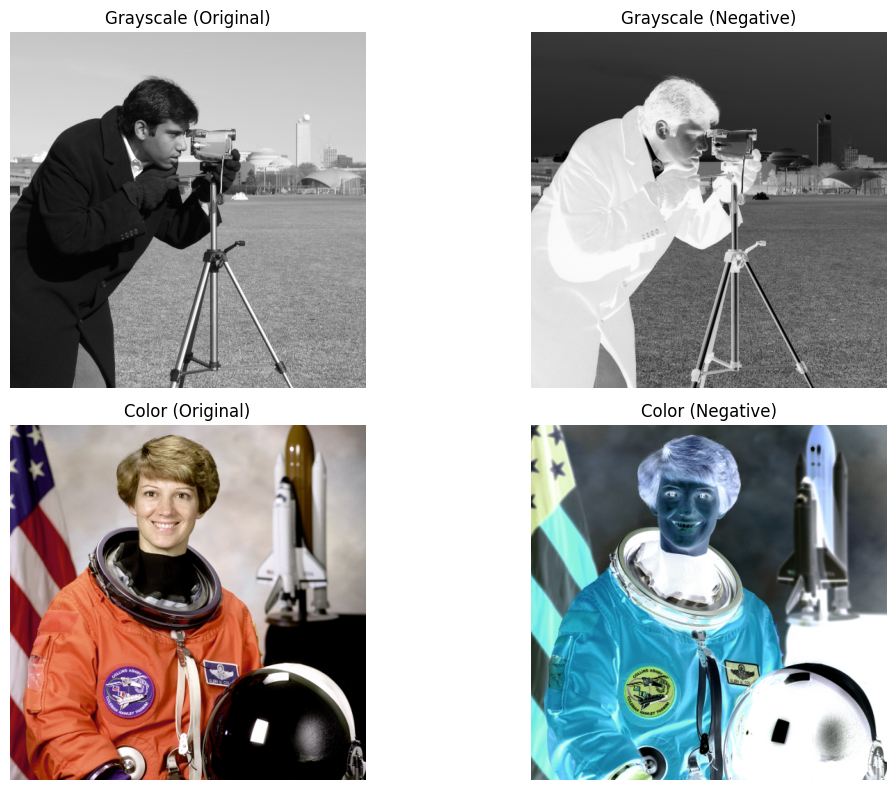

In [ ]:
# Praktikum_01
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float

# ===================
# 1. TRANSFORMASI NEGATIF CITRA GRAYSCALE
# ===================
image_gray_uint8 = data.camera()  # Citra grayscale (512x512, 0..255)
image_gray_float = img_as_float(image_gray_uint8)  # Konversi ke float [0..1]

negative_gray = 1.0 - image_gray_float  # Inversi intensitas: output = 1 - input

# ===================
# 2. TRANSFORMASI NEGATIF CITRA BERWARNA
# ===================
image_color_uint8 = data.astronaut()  # Citra berwarna (512x512x3, 0..255)
image_color_float = img_as_float(image_color_uint8)  # Konversi ke float [0..1]

negative_color = 1.0 - image_color_float  # Inversi intensitas tiap kanal RGB

# ===================
# 3. PLOTTING HASIL
# ===================
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Baris 1: Grayscale (original, negative)
axes[0, 0].imshow(image_gray_float, cmap='gray')
axes[0, 0].set_title("Grayscale (Original)")
axes[0, 0].axis('off')

axes[0, 1].imshow(negative_gray, cmap='gray')
axes[0, 1].set_title("Grayscale (Negative)")
axes[0, 1].axis('off')

# Baris 2: RGB (original, negative)
axes[1, 0].imshow(image_color_float)
axes[1, 0].set_title("Color (Original)")
axes[1, 0].axis('off')

axes[1, 1].imshow(negative_color)
axes[1, 1].set_title("Color (Negative)")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()


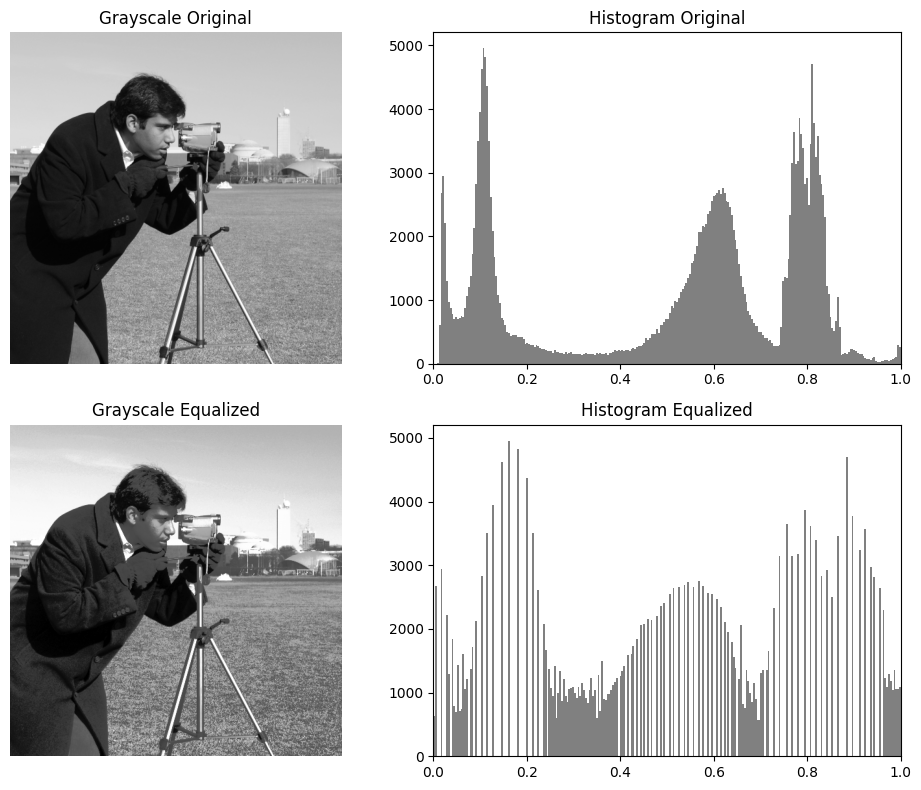

In [ ]:
#Praktikum_02
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure, img_as_float

# -----------------------------------------------------
# HISTOGRAM & EKUALISASI HISTOGRAM (GRAYSCALE)
# -----------------------------------------------------

# 1. Memuat citra grayscale
image_gray_uint8 = data.camera()  # citra grayscale (uint8, 0..255)
image_gray = img_as_float(image_gray_uint8)  # konversi ke float [0..1]

# 2. Menghitung histogram citra asli
hist_gray, bins_gray = np.histogram(image_gray.ravel(), bins=256, range=(0, 1))

# 3. Ekualisasi histogram
image_gray_eq = exposure.equalize_hist(image_gray)
hist_gray_eq, bins_gray_eq = np.histogram(image_gray_eq.ravel(), bins=256, range=(0, 1))

# 4. Plot: citra asli & histogram, citra ekualisasi & histogram
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# (a) Citra Asli Grayscale
axes[0, 0].imshow(image_gray, cmap='gray')
axes[0, 0].set_title("Grayscale Original")
axes[0, 0].axis('off')

# (b) Histogram Citra Asli
axes[0, 1].hist(image_gray.ravel(), bins=256, range=(0, 1), color='gray')
axes[0, 1].set_title("Histogram Original")
axes[0, 1].set_xlim(0, 1)

# (c) Citra Hasil Ekualisasi
axes[1, 0].imshow(image_gray_eq, cmap='gray')
axes[1, 0].set_title("Grayscale Equalized")
axes[1, 0].axis('off')

# (d) Histogram Hasil Ekualisasi
axes[1, 1].hist(image_gray_eq.ravel(), bins=256, range=(0, 1), color='gray')
axes[1, 1].set_title("Histogram Equalized")
axes[1, 1].set_xlim(0, 1)

plt.tight_layout()
plt.show()


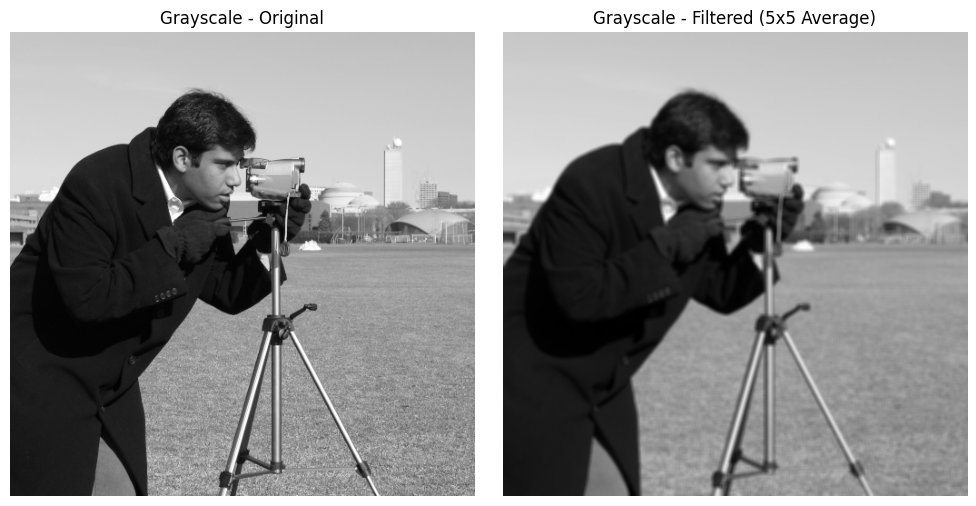

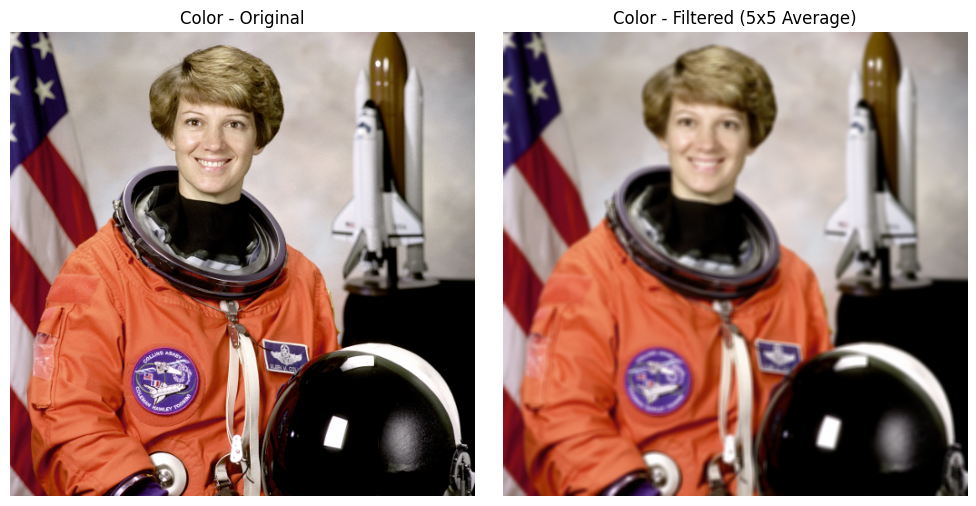

In [ ]:
#Praktikum_03
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from scipy import ndimage as ndi

# --------------------------------------------------
# 1) FILTER RATA-RATA PADA CITRA GRAYSCALE
# --------------------------------------------------

# A. Memuat citra grayscale
gray_uint8 = data.camera()  # range 0..255
gray_img = img_as_float(gray_uint8)  # konversi menjadi float [0..1]

# B. Definisikan kernel filter rata-rata (contoh: 5x5)
kernel_size = 5
kernel = np.ones((kernel_size, kernel_size), dtype=float) / (kernel_size * kernel_size)

# C. Lakukan konvolusi pada citra grayscale
gray_filtered = ndi.convolve(gray_img, kernel, mode='reflect')

# D. Tampilkan hasil grayscale
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(gray_img, cmap='gray')
axes[0].set_title("Grayscale - Original")
axes[0].axis('off')

axes[1].imshow(gray_filtered, cmap='gray')
axes[1].set_title(f"Grayscale - Filtered ({kernel_size}x{kernel_size} Average)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

# --------------------------------------------------
# 2) FILTER RATA-RATA PADA CITRA BERWARNA
# --------------------------------------------------

# A. Memuat citra berwarna
color_uint8 = data.astronaut()  # citra RGB (uint8, 0..255)
color_img = img_as_float(color_uint8)  # konversi ke float [0..1]

# B. Terapkan filter rata-rata pada tiap kanal (R, G, B)
color_filtered = np.zeros_like(color_img)

for c in range(3):  # 0 = Red, 1 = Green, 2 = Blue
    color_filtered[:, :, c] = ndi.convolve(color_img[:, :, c], kernel, mode='reflect')

# C. Tampilkan hasil citra berwarna
fig2, axes2 = plt.subplots(1, 2, figsize=(10, 5))
axes2[0].imshow(color_img)
axes2[0].set_title("Color - Original")
axes2[0].axis('off')

axes2[1].imshow(color_filtered)
axes2[1].set_title(f"Color - Filtered ({kernel_size}x{kernel_size} Average)")
axes2[1].axis('off')

plt.tight_layout()
plt.show()


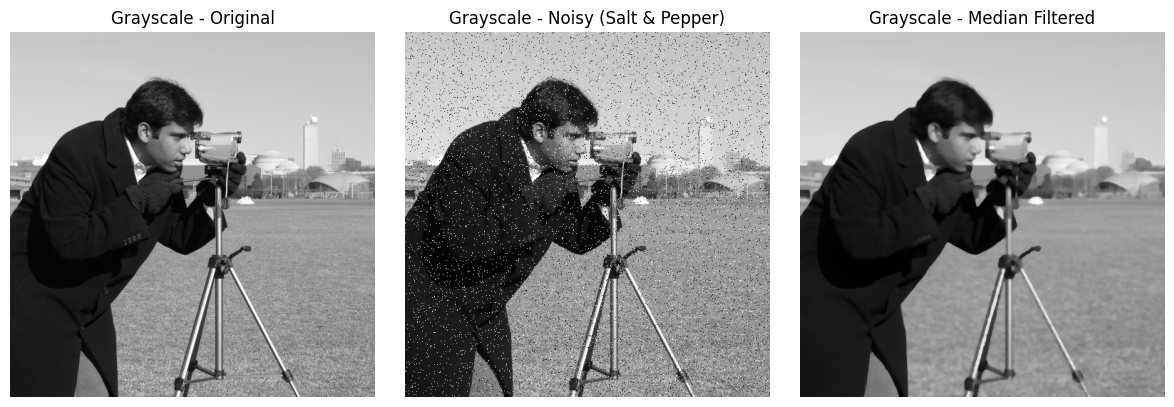

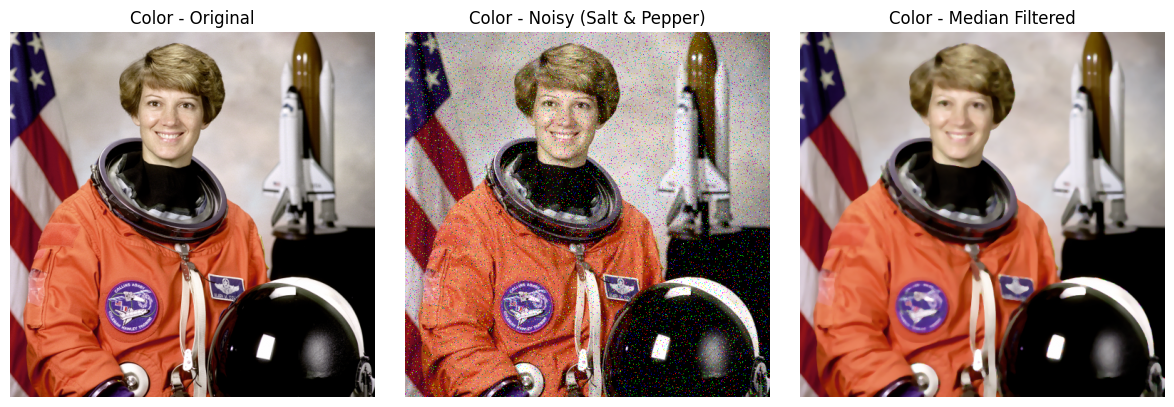

In [ ]:
#Praktikum_04
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, util, filters, morphology, img_as_float

# -----------------------------------------
# 1) FILTER MEDIAN PADA CITRA GRAYSCALE
# -----------------------------------------

# A. Memuat citra grayscale (contoh: 'camera')
gray_uint8 = data.camera()  # grayscale, uint8
gray_float = img_as_float(gray_uint8)  # konversi ke float [0..1]

# B. Menambahkan noise jenis salt-and-pepper
gray_noisy = util.random_noise(gray_float, mode='s&p', amount=0.05)  # 5% noise

# C. Menerapkan filter median dengan elemen struktural disk radius 3
disk3 = morphology.disk(3)
gray_denoised = filters.median(gray_noisy, disk3)

# D. Plot hasil
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(gray_float, cmap='gray')
axes[0].set_title("Grayscale - Original")
axes[0].axis('off')

axes[1].imshow(gray_noisy, cmap='gray')
axes[1].set_title("Grayscale - Noisy (Salt & Pepper)")
axes[1].axis('off')

axes[2].imshow(gray_denoised, cmap='gray')
axes[2].set_title("Grayscale - Median Filtered")
axes[2].axis('off')

plt.tight_layout()
plt.show()

# -----------------------------------------
# 2) FILTER MEDIAN PADA CITRA BERWARNA
# -----------------------------------------

# A. Memuat citra berwarna (contoh: 'astronaut')
color_uint8 = data.astronaut()  # RGB, uint8
color_float = img_as_float(color_uint8)  # konversi ke float [0..1]

# B. Menambahkan noise salt-and-pepper
color_noisy = util.random_noise(color_float, mode='s&p', amount=0.05)

# C. Menerapkan filter median per kanal warna
color_denoised = np.zeros_like(color_noisy)
for c in range(3):  # 0 = R, 1 = G, 2 = B
    color_denoised[:, :, c] = filters.median(color_noisy[:, :, c], morphology.disk(3))

# D. Plot hasil
fig2, axes2 = plt.subplots(1, 3, figsize=(12, 4))
axes2[0].imshow(color_float)
axes2[0].set_title("Color - Original")
axes2[0].axis('off')

axes2[1].imshow(color_noisy)
axes2[1].set_title("Color - Noisy (Salt & Pepper)")
axes2[1].axis('off')

axes2[2].imshow(color_denoised)
axes2[2].set_title("Color - Median Filtered")
axes2[2].axis('off')

plt.tight_layout()
plt.show()


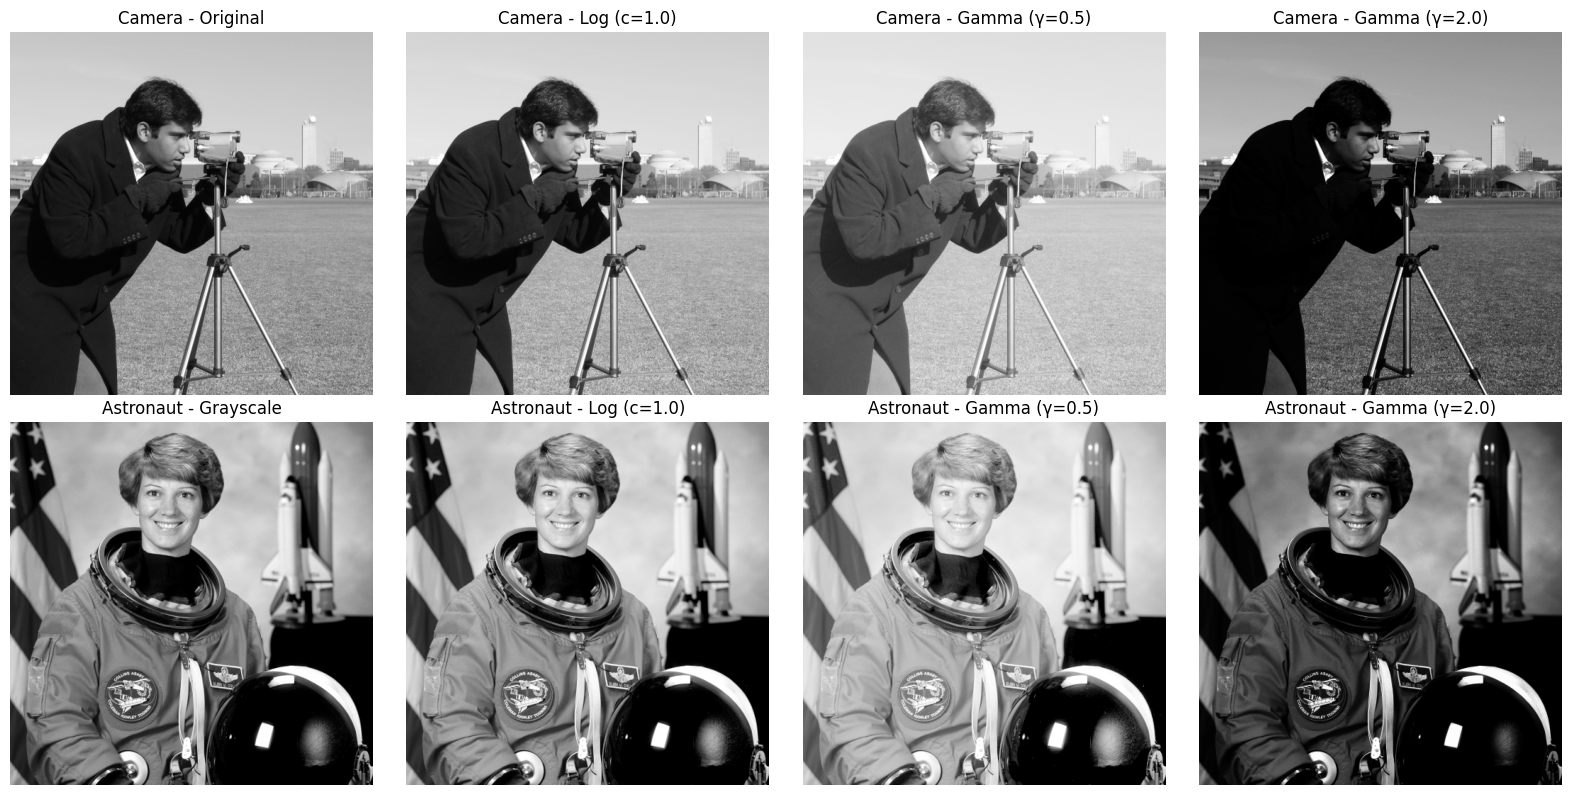

=== Penjelasan Transformasi Intensitas ===

[Log Transform - c=1.0]
- Transformasi logaritmik memperbesar nilai rendah (area gelap),
  sehingga detail di area gelap menjadi lebih terlihat.
- Semakin besar nilai 'c', citra akan tampak lebih terang secara keseluruhan.

[Gamma Transform - gamma=0.5]
- Gamma < 1 memperkuat nilai intensitas rendah, sehingga citra terlihat lebih cerah.
- Cocok untuk memperjelas detail pada daerah gelap.

[Gamma Transform - gamma=2.0]
- Gamma > 1 menurunkan nilai intensitas rendah dan sedang.
- Hasilnya, citra menjadi lebih gelap dan detail terang jadi lebih menonjol.
- Cocok untuk mengurangi efek terlalu terang (highlight).

Kesimpulan:
- Transformasi ini berguna untuk menyesuaikan rentang kontras sesuai kebutuhan analisis.
- Dapat digunakan sebagai pre-processing untuk segmentasi atau deteksi tepi.


In [9]:
#Eksperimen Transformasi Intensitas Lain
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, img_as_float

# ----------------------------
# Fungsi Transformasi
# ----------------------------
def log_transform(image, c=1):
    image = c * np.log1p(image)  # log(1 + r)
    return image / image.max()   # normalisasi agar tetap di [0, 1]

def gamma_transform(image, gamma=1.0, c=1):
    image = c * np.power(image, gamma)
    return image / image.max()   # normalisasi

# ----------------------------
# 1. Memuat Citra
# ----------------------------
img_camera = img_as_float(data.camera())
img_astronaut_rgb = data.astronaut()
img_astronaut_gray = img_as_float(color.rgb2gray(img_astronaut_rgb))

# ----------------------------
# 2. Parameter Transformasi
# ----------------------------
c_log = 1.0
gamma_low = 0.5   # mempercerah
gamma_high = 2.0  # menggelapkan

# ----------------------------
# 3. Proses Transformasi
# ----------------------------
log_camera = log_transform(img_camera, c=c_log)
log_astronaut = log_transform(img_astronaut_gray, c=c_log)

gamma_low_camera = gamma_transform(img_camera, gamma=gamma_low)
gamma_high_camera = gamma_transform(img_camera, gamma=gamma_high)

gamma_low_astronaut = gamma_transform(img_astronaut_gray, gamma=gamma_low)
gamma_high_astronaut = gamma_transform(img_astronaut_gray, gamma=gamma_high)

# ----------------------------
# 4. Menampilkan Hasil
# ----------------------------
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

images = [
    (img_camera, 'Camera - Original'),
    (log_camera, f'Camera - Log (c={c_log})'),
    (gamma_low_camera, f'Camera - Gamma (γ={gamma_low})'),
    (gamma_high_camera, f'Camera - Gamma (γ={gamma_high})'),

    (img_astronaut_gray, 'Astronaut - Grayscale'),
    (log_astronaut, f'Astronaut - Log (c={c_log})'),
    (gamma_low_astronaut, f'Astronaut - Gamma (γ={gamma_low})'),
    (gamma_high_astronaut, f'Astronaut - Gamma (γ={gamma_high})'),
]

for ax, (img, title) in zip(axes.ravel(), images):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

# ----------------------------
# 5. Penjelasan Hasil
# ----------------------------
print("=== Penjelasan Transformasi Intensitas ===\n")

# Log Transform
print(f"[Log Transform - c={c_log}]")
print("- Transformasi logaritmik memperbesar nilai rendah (area gelap),")
print("  sehingga detail di area gelap menjadi lebih terlihat.")
print("- Semakin besar nilai 'c', citra akan tampak lebih terang secara keseluruhan.\n")

# Gamma Transform (gamma < 1)
print(f"[Gamma Transform - gamma={gamma_low}]")
print("- Gamma < 1 memperkuat nilai intensitas rendah, sehingga citra terlihat lebih cerah.")
print("- Cocok untuk memperjelas detail pada daerah gelap.\n")

# Gamma Transform (gamma > 1)
print(f"[Gamma Transform - gamma={gamma_high}]")
print("- Gamma > 1 menurunkan nilai intensitas rendah dan sedang.")
print("- Hasilnya, citra menjadi lebih gelap dan detail terang jadi lebih menonjol.")
print("- Cocok untuk mengurangi efek terlalu terang (highlight).\n")

print("Kesimpulan:")
print("- Transformasi ini berguna untuk menyesuaikan rentang kontras sesuai kebutuhan analisis.")
print("- Dapat digunakan sebagai pre-processing untuk segmentasi atau deteksi tepi.")


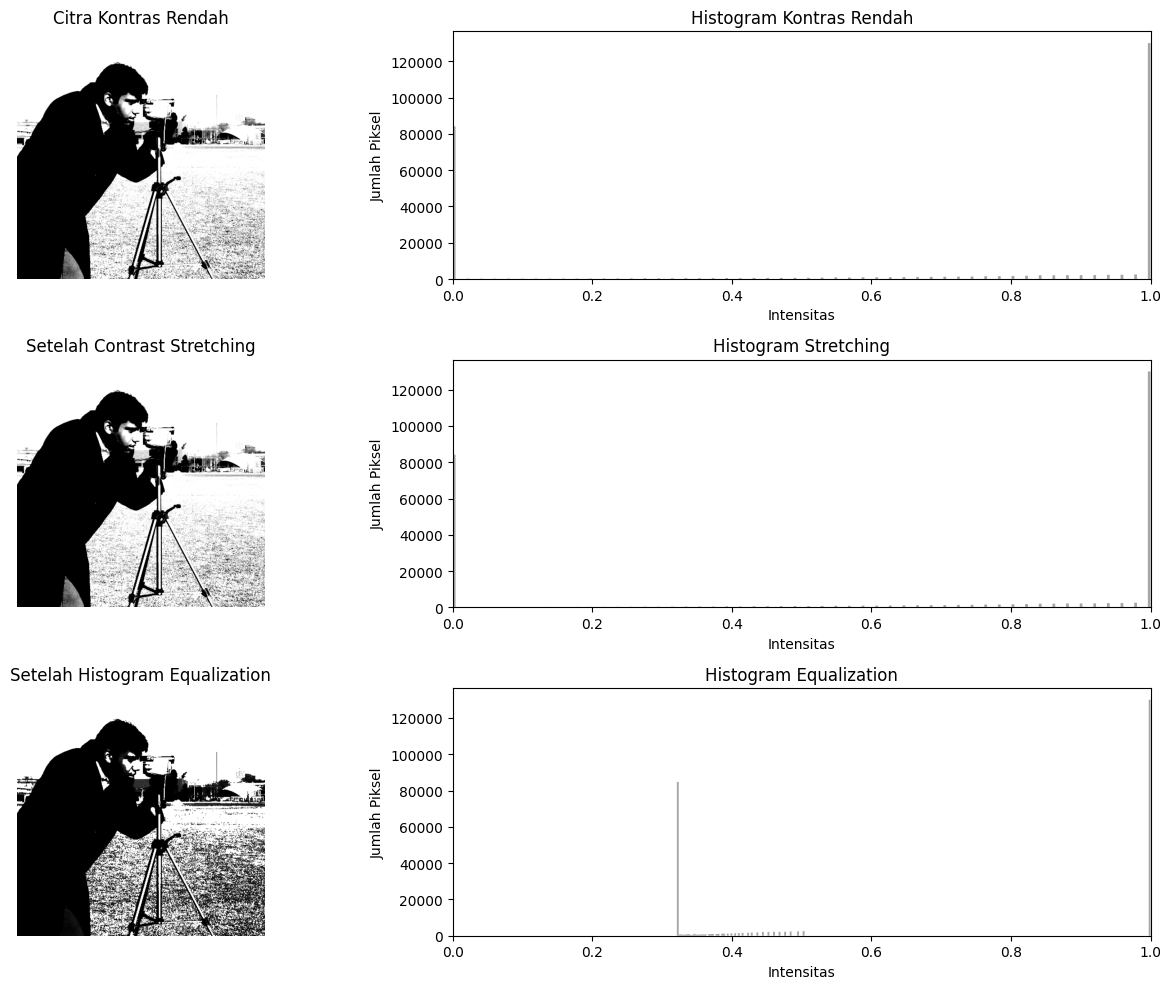

=== ANALISIS PERBANDINGAN ===

[1] Contrast Stretching:
- Meningkatkan kontras dengan memperluas rentang intensitas piksel berdasarkan nilai min dan max yang ada.
- Cocok jika kita tahu range kontras citra tidak penuh dan ingin merenggangkan nilai agar menyebar ke [0, 1].
- Hasilnya tetap mempertahankan bentuk distribusi intensitas asli, hanya saja direnggangkan.

[2] Histogram Equalization:
- Menyebarkan nilai piksel secara merata di seluruh histogram.
- Lebih agresif daripada stretching — memperjelas kontras di seluruh tingkat kecerahan.
- Kadang menghasilkan artefak seperti efek berlebihan pada gradasi halus atau tekstur.

>>> Kesimpulan:
- Jika ingin hasil alami dan mempertahankan struktur kontras asli → gunakan **Contrast Stretching**.
- Jika ingin peningkatan kontras maksimal di seluruh area terang dan gelap → gunakan **Histogram Equalization**.
- Pemilihan metode tergantung kebutuhan aplikasi: penglihatan visual, analisis tekstur, atau segmentasi citra.


In [13]:
#Perbandingan Metode Peningkatan Kontras
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float, exposure

# ----------------------------
# 1. Memuat Citra Grayscale Kontras Rendah
# ----------------------------
original = img_as_float(data.camera())
low_contrast = exposure.rescale_intensity(original, in_range=(0.4, 0.6))

# ----------------------------
# 2. Metode Peningkatan Kontras
# ----------------------------
stretched = exposure.rescale_intensity(low_contrast, in_range='image', out_range=(0, 1))
equalized = exposure.equalize_hist(low_contrast)

# ----------------------------
# 3. Fungsi untuk Plot Histogram
# ----------------------------
def plot_histogram(image, ax, title):
    ax.hist(image.ravel(), bins=256, histtype='stepfilled', color='gray', alpha=0.7)
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_xlabel('Intensitas')
    ax.set_ylabel('Jumlah Piksel')

# ----------------------------
# 4. Tampilkan Hasil Citra dan Histogram
# ----------------------------
fig, axes = plt.subplots(3, 2, figsize=(14, 10))

# Baris 1 - Citra Kontras Rendah
axes[0, 0].imshow(low_contrast, cmap='gray')
axes[0, 0].set_title('Citra Kontras Rendah')
axes[0, 0].axis('off')
plot_histogram(low_contrast, axes[0, 1], 'Histogram Kontras Rendah')

# Baris 2 - Contrast Stretching
axes[1, 0].imshow(stretched, cmap='gray')
axes[1, 0].set_title('Setelah Contrast Stretching')
axes[1, 0].axis('off')
plot_histogram(stretched, axes[1, 1], 'Histogram Stretching')

# Baris 3 - Histogram Equalization
axes[2, 0].imshow(equalized, cmap='gray')
axes[2, 0].set_title('Setelah Histogram Equalization')
axes[2, 0].axis('off')
plot_histogram(equalized, axes[2, 1], 'Histogram Equalization')

plt.tight_layout()
plt.show()

# ----------------------------
# 5. Analisis dan Penjelasan
# ----------------------------
print("=== ANALISIS PERBANDINGAN ===\n")

print("[1] Contrast Stretching:")
print("- Meningkatkan kontras dengan memperluas rentang intensitas piksel berdasarkan nilai min dan max yang ada.")
print("- Cocok jika kita tahu range kontras citra tidak penuh dan ingin merenggangkan nilai agar menyebar ke [0, 1].")
print("- Hasilnya tetap mempertahankan bentuk distribusi intensitas asli, hanya saja direnggangkan.\n")

print("[2] Histogram Equalization:")
print("- Menyebarkan nilai piksel secara merata di seluruh histogram.")
print("- Lebih agresif daripada stretching — memperjelas kontras di seluruh tingkat kecerahan.")
print("- Kadang menghasilkan artefak seperti efek berlebihan pada gradasi halus atau tekstur.\n")

print(">>> Kesimpulan:")
print("- Jika ingin hasil alami dan mempertahankan struktur kontras asli → gunakan **Contrast Stretching**.")
print("- Jika ingin peningkatan kontras maksimal di seluruh area terang dan gelap → gunakan **Histogram Equalization**.")
print("- Pemilihan metode tergantung kebutuhan aplikasi: penglihatan visual, analisis tekstur, atau segmentasi citra.")


C:\Users\ACER\AppData\Local\Temp\ipykernel_22456\3658556444.py:22: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  median_filtered = filters.median(noisy_img, morphology.square(kernel_size))


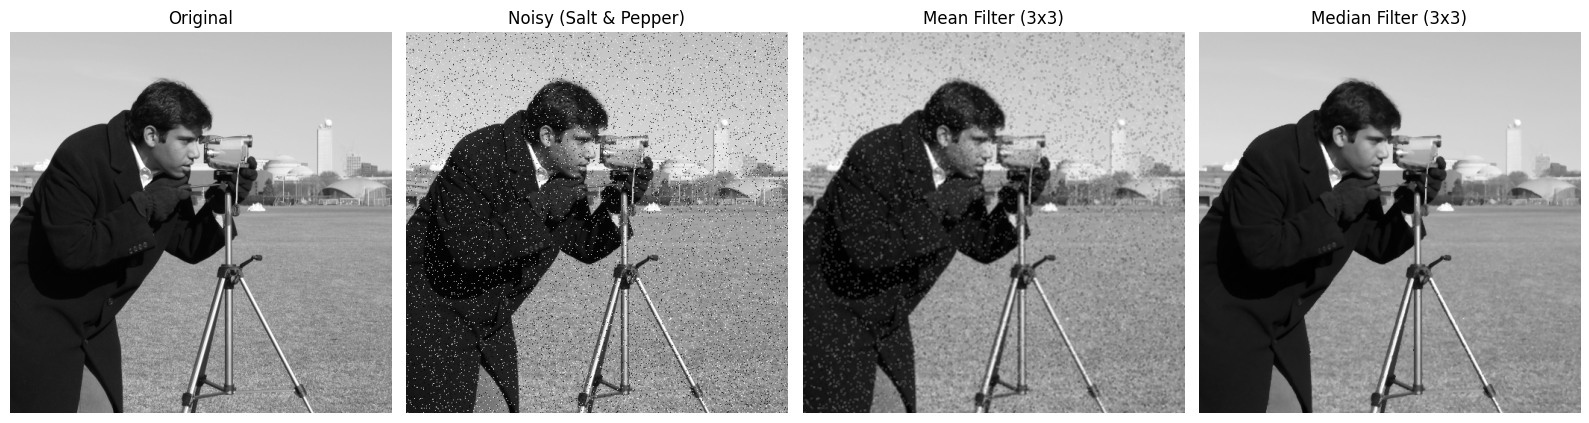

=== ANALISIS PERBANDINGAN FILTER ===

[Filter Rata-rata (Mean Filter)]:
- Menghitung rata-rata dari piksel sekitar.
- Cenderung mengaburkan noise, tetapi juga mengaburkan tepi objek.
- Tidak efektif menghilangkan noise salt-and-pepper karena nilai ekstrim tetap mempengaruhi rata-rata.

[Filter Median]:
- Mengambil nilai tengah dari piksel sekitar (bukan rata-rata).
- Sangat efektif menghilangkan noise salt-and-pepper karena nilai ekstrem diabaikan.
- Menjaga tepi objek lebih baik dibandingkan filter rata-rata.

>>> Kesimpulan:
- **Filter median lebih unggul** dalam mengatasi noise impuls (salt-and-pepper).
- **Filter rata-rata** cenderung mengaburkan citra secara keseluruhan tanpa benar-benar menghilangkan noise ekstrem.


In [12]:
#Filter Median vs Filter Rata-rata
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float, util, filters, morphology
from scipy.ndimage import convolve

# ----------------------------
# 1. Memuat citra dan menambahkan noise
# ----------------------------
img = img_as_float(data.camera())  # citra grayscale
noisy_img = util.random_noise(img, mode='s&p', amount=0.05)  # salt & pepper noise 5%

# ----------------------------
# 2. Filter Rata-rata (Mean Filter)
# ----------------------------
kernel_size = 3
mean_kernel = np.ones((kernel_size, kernel_size)) / (kernel_size * kernel_size)
mean_filtered = convolve(noisy_img, mean_kernel, mode='reflect')

# ----------------------------
# 3. Filter Median
# ----------------------------
median_filtered = filters.median(noisy_img, morphology.square(kernel_size))

# ----------------------------
# 4. Visualisasi Hasil
# ----------------------------
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(noisy_img, cmap='gray')
axes[1].set_title('Noisy (Salt & Pepper)')
axes[1].axis('off')

axes[2].imshow(mean_filtered, cmap='gray')
axes[2].set_title(f'Mean Filter ({kernel_size}x{kernel_size})')
axes[2].axis('off')

axes[3].imshow(median_filtered, cmap='gray')
axes[3].set_title(f'Median Filter ({kernel_size}x{kernel_size})')
axes[3].axis('off')

plt.tight_layout()
plt.show()

# ----------------------------
# 5. Analisis dan Penjelasan
# ----------------------------
print("=== ANALISIS PERBANDINGAN FILTER ===\n")

print("[Filter Rata-rata (Mean Filter)]:")
print("- Menghitung rata-rata dari piksel sekitar.")
print("- Cenderung mengaburkan noise, tetapi juga mengaburkan tepi objek.")
print("- Tidak efektif menghilangkan noise salt-and-pepper karena nilai ekstrim tetap mempengaruhi rata-rata.\n")

print("[Filter Median]:")
print("- Mengambil nilai tengah dari piksel sekitar (bukan rata-rata).")
print("- Sangat efektif menghilangkan noise salt-and-pepper karena nilai ekstrem diabaikan.")
print("- Menjaga tepi objek lebih baik dibandingkan filter rata-rata.\n")

print(">>> Kesimpulan:")
print("- **Filter median lebih unggul** dalam mengatasi noise impuls (salt-and-pepper).")
print("- **Filter rata-rata** cenderung mengaburkan citra secara keseluruhan tanpa benar-benar menghilangkan noise ekstrem.")
